# Coursera Data Courses

Scraping Data from a Dynamic Webpage using Selenium and BeautifulSoup

## Objective
The goal of this project is to collect and analyze data from Coursera courses that are relevant as of March 2026, using web scraping techniques.

We aim to:
- Extract structured data (course title, provider, rating, level, skills)
- Perform exploratory data analysis (EDA)
- Identify patterns in course offerings, ratings, and skill demand

## Tools Used
- Python
- Selenium & BeautifulSoup (for web scraping dynamic, JavaScript-generated content)
- Pandas (data analysis)
- Matplotlib & Seaborn (visualization)

> This analysis provides insights into current trends in data education.

In [25]:
# ===============================
#  Install necessary packages
#  Import libraries
# ===============================
!pip install -q google-colab-selenium beautifulsoup4

import pandas as pd
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import google_colab_selenium as gs
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, StaleElementReferenceException
from bs4 import BeautifulSoup # Import BeautifulSoup

sns.set(style="whitegrid")
print("✅ Libraries loaded and ready!")



# ===============================
# ROBUST COURSERA SCRAPING
# ===============================

#Initialize Selenium driver
driver = gs.Chrome()
url = "https://www.coursera.org/search?query=data"
driver.get(url)

# Wait for something to load
WebDriverWait(driver, 15).until(
    EC.presence_of_element_located((By.TAG_NAME, "body"))
)

print("Page loaded... scrolling 🔄")

# SCROLL to force course loading
for _ in range(6):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

print("Scroll done")

# Wait for titles to appear
WebDriverWait(driver, 15).until(
    EC.presence_of_element_located((By.CLASS_NAME, "cds-CommonCard-title"))
)

# Capture elements
titles = driver.find_elements(By.CLASS_NAME, "cds-CommonCard-title")
print(f"Titles found: {len(titles)}")

data = []

for t in titles:
    try:
        parent = t.find_element(By.XPATH, "./ancestor::div[contains(@class, 'cds-CommonCard')]")
        text = parent.text.strip()
        if text:
            data.append(text)      #Store in a list
    except:
        continue

driver.quit()

print(f"Courses captured: {len(data)}")

# Quick Verification
for d in data[:5]:
    print(d)
    print("-----")

✅ Libraries loaded and ready!


<IPython.core.display.Javascript object>

Page loaded... scrolling 🔄
Scroll done
Titles found: 12
Courses captured: 12
IBM
Introduction to Data Analytics
Skills you'll gain: Data Storytelling, Data Wrangling, Data Presentation, Big Data, Data Analysis, Data Cleansing, Apache Hadoop, Statistical Analysis, Data Visualization, Apache Hive, Data Mart, Data Warehousing, Apache Spark, Data Science, Analytics, Data Lakes, Data Collection, Microsoft Excel
4.8
Rating, 4.8 out of 5 stars
·
20K reviews
Beginner · Course · 1 - 3 Months
-----
IBM
Data Analysis with Python
Skills you'll gain: Exploratory Data Analysis, Data Analysis, Data Import/Export, Data Manipulation, Data Transformation, Predictive Modeling, Data Cleansing, Data Preprocessing, Model Evaluation, Predictive Analytics, Pandas (Python Package), Regression Analysis, Feature Engineering, Statistical Analysis, Matplotlib, Scikit Learn (Machine Learning Library), Data Visualization, NumPy, Python Programming
4.7
Rating, 4.7 out of 5 stars
·
20K reviews
Intermediate · Course · 

In [26]:
# ===============================
# Convert scraped data into a pandas DataFrame
# Preview first rows
# ===============================
df = pd.DataFrame(data, columns=["raw_text"])
display(df.head(5))

# ===============================
# Extraction functions
# ===============================

# course title and provider
def extract_title_and_provider(text):
    clean_text = re.sub(r"^(Status:.*?|Bestseller)", "", text).strip()
    parts = clean_text.split("Skills you'll gain:")
    pre_skills = parts[0].strip() if parts else clean_text
    lines = [line.strip() for line in pre_skills.split("\n") if line.strip()]

    provider = None
    title = None
    known_providers = ["IBM", "Google", "Microsoft", "Duke", "Yale", "PwC", "Coursera"]

    for i, line in enumerate(lines):
        for p in known_providers:
            if p in line:
                provider = p
                remainder = line.replace(p, '').strip()
                if remainder:
                    title = remainder
                elif i + 1 < len(lines):
                    title = lines[i + 1]
                break
        if provider:
            break

    if not title and lines:
        title = lines[-1]

    return title, provider

#  skills
def extract_skills(text):
    match = re.search(r"Skills you'll gain:(.*?)(\d\.\d\sRating|$)", text, re.DOTALL)
    if match:
        skills = match.group(1).replace("\n"," ").strip()
        return skills if skills else None
    return None

# rating
def extract_rating(text):
    match = re.search(r"(\d\.\d)\sRating", text)
    return float(match.group(1)) if match else None

# number of reviews
def extract_reviews(text):
    match = re.search(r"([\d,\.K]+)\s*reviews", text)
    if match:
        return match.group(1)
    return None

# level
def extract_level(text):
    for level in ["Beginner", "Intermediate", "Advanced"]:
        if level in text:
            return level
    return None

# course type
def extract_type(text):
    for t in ["Course", "Professional Certificate", "Specialization"]:
        if t in text:
            return t
    return None

# duration
def extract_duration(text):
    match = re.search(r"\d+\s-\s\d+\s(?:Weeks|Months)", text)
    return match.group(0) if match else None

# ===============================
# Apply functions to the DataFrame
# ===============================
df[['title','provider']] = df['raw_text'].apply(lambda x: pd.Series(extract_title_and_provider(x)))
df['skills'] = df['raw_text'].apply(extract_skills)
df['rating'] = df['raw_text'].apply(extract_rating)
df['reviews'] = df['raw_text'].apply(extract_reviews)
df['level'] = df['raw_text'].apply(extract_level)
df['type'] = df['raw_text'].apply(extract_type)
df['duration'] = df['raw_text'].apply(extract_duration).fillna("Varies")

df_clean = df[['title','provider','skills','rating','reviews','level','type','duration']]
display(df_clean)


,raw_text
0,IBM\nIntroduction to Data Analytics\nSkills yo...
1,IBM\nData Analysis with Python\nSkills you'll ...
2,Google\nGoogle Data Analytics\nSkills you'll g...
3,"Google\nFoundations: Data, Data, Everywhere\nS..."
4,IBM\nExcel Basics for Data Analysis\nSkills yo...


,title,provider,skills,rating,reviews,level,type,duration
0,Introduction to Data Analytics,IBM,"Data Storytelling, Data Wrangling, Data Presen...",4.8,20K,Beginner,Course,1 - 3 Months
1,Data Analysis with Python,IBM,"Exploratory Data Analysis, Data Analysis, Data...",4.7,20K,Intermediate,Course,1 - 3 Months
2,Google Data Analytics,Google,"Data Storytelling, Rmarkdown, Data Literacy, D...",4.8,178K,Beginner,Professional Certificate,3 - 6 Months
3,"Foundations: Data, Data, Everywhere",Google,"Data Ethics, Data Analysis, Analytics, Data-Dr...",4.8,122K,Beginner,Course,1 - 4 Weeks
4,Excel Basics for Data Analysis,IBM,"Excel Formulas, Pivot Tables And Charts, Data ...",4.7,11K,Beginner,Course,1 - 3 Months
5,Data-driven Decision Making,PwC,"Analytics, Business Analytics, Data Analysis, ...",4.6,6.2K,Beginner,Course,1 - 4 Weeks
6,IBM Data Analyst,IBM,"Data Storytelling, Dashboard, Data Presentatio...",4.6,98K,Beginner,Professional Certificate,3 - 6 Months
7,Google Advanced Data Analytics,Google,"Data Storytelling, Data Visualization, A/B Tes...",4.8,11K,Advanced,Professional Certificate,3 - 6 Months
8,Introduction to Data Engineering,IBM,"Extract, Transform, Load, Data Architecture, D...",4.7,3.6K,Beginner,Course,1 - 4 Weeks
9,IBM Data Science,IBM,"Data Storytelling, Dashboard, Data Presentatio...",4.6,150K,Beginner,Professional Certificate,3 - 6 Months


In [27]:

# ===============================
# Exploratory Data Analysis (EDA)
# ===============================
print("=== Head ===")
display(df_clean.head(5))

print("\n=== Info ===")
print(df_clean.info())

print("\n=== Missing values ===")
print(df_clean.isna().sum())  # Some missing values in skills/reviews (expected due to scraping variability)

print("\n=== Duplicates ===")
print(df_clean.duplicated().sum())  #No duplicates

# ===============================
# Clean reviews and convert to numeric
# ===============================
def reviews_to_number(x):
    if pd.isna(x):
        return None
    x = x.replace(',','').strip()
    if 'K' in x:
        try:
            return int(float(x.replace('K','')) * 1000)
        except:
            return None
    try:
        return int(x)
    except:
        return None

df_clean['reviews_num'] = df_clean['reviews'].apply(reviews_to_number)


=== Head ===


,title,provider,skills,rating,reviews,level,type,duration
0,Introduction to Data Analytics,IBM,"Data Storytelling, Data Wrangling, Data Presen...",4.8,20K,Beginner,Course,1 - 3 Months
1,Data Analysis with Python,IBM,"Exploratory Data Analysis, Data Analysis, Data...",4.7,20K,Intermediate,Course,1 - 3 Months
2,Google Data Analytics,Google,"Data Storytelling, Rmarkdown, Data Literacy, D...",4.8,178K,Beginner,Professional Certificate,3 - 6 Months
3,"Foundations: Data, Data, Everywhere",Google,"Data Ethics, Data Analysis, Analytics, Data-Dr...",4.8,122K,Beginner,Course,1 - 4 Weeks
4,Excel Basics for Data Analysis,IBM,"Excel Formulas, Pivot Tables And Charts, Data ...",4.7,11K,Beginner,Course,1 - 3 Months



=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   title     12 non-null     object 
 1   provider  12 non-null     object 
 2   skills    12 non-null     object 
 3   rating    12 non-null     float64
 4   reviews   12 non-null     object 
 5   level     12 non-null     object 
 6   type      12 non-null     object 
 7   duration  12 non-null     object 
dtypes: float64(1), object(7)
memory usage: 900.0+ bytes
None

=== Missing values ===
title       0
provider    0
skills      0
rating      0
reviews     0
level       0
type        0
duration    0
dtype: int64

=== Duplicates ===
0


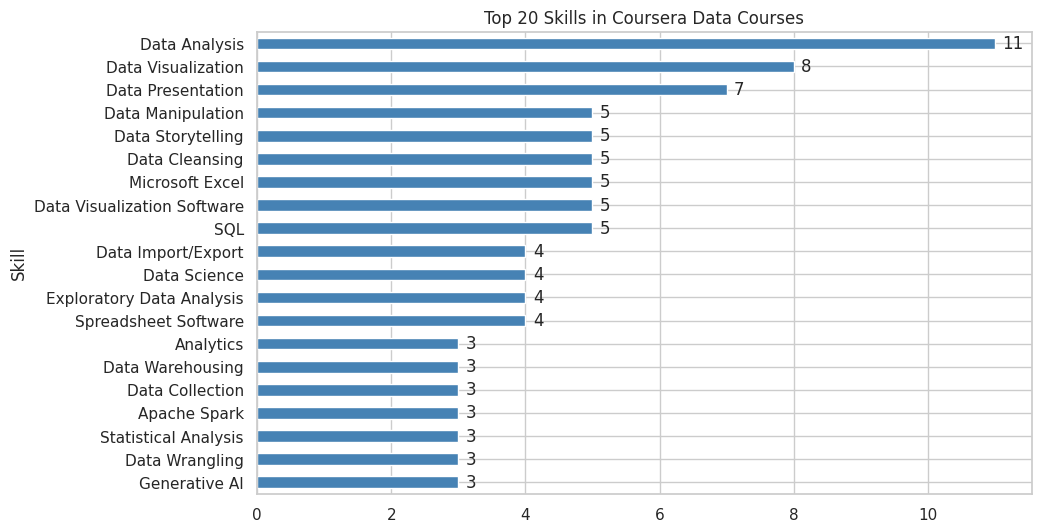

,Skill,Count
4,Data Analysis,11
8,Data Visualization,8
2,Data Presentation,7
20,Data Manipulation,5
0,Data Storytelling,5
5,Data Cleansing,5
17,Microsoft Excel,5
54,Data Visualization Software,5
55,SQL,5
19,Data Import/Export,4


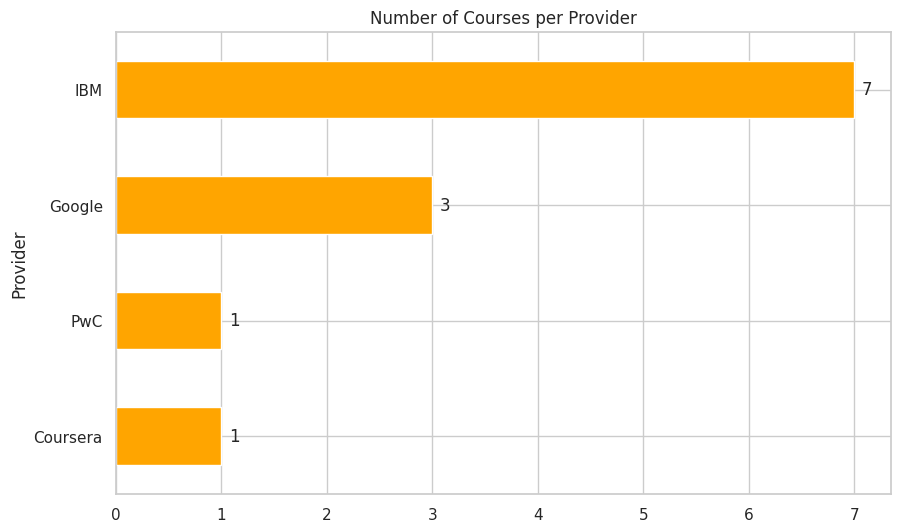

,Provider,Count
0,IBM,7
1,Google,3
2,PwC,1
3,Coursera,1


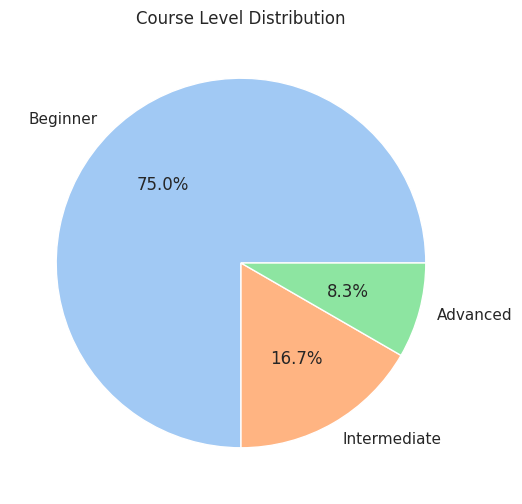

,count
level,
Beginner,9
Intermediate,2
Advanced,1


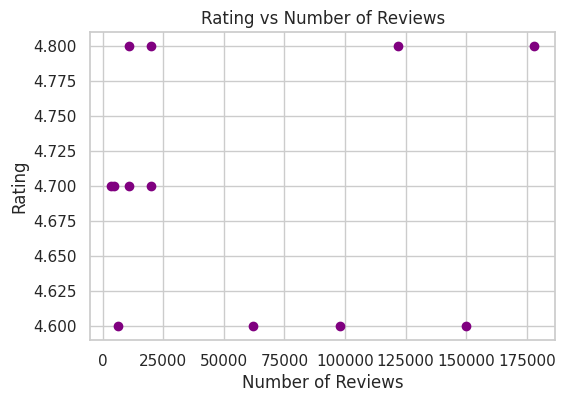

In [28]:
print()

# ===============================
# Convert skills into lists and count frequency
# ===============================
df_clean['skills_list'] = df_clean['skills'].apply(lambda x: [s.strip() for s in x.split(",")] if x else [])
all_skills = [skill for sublist in df_clean['skills_list'] for skill in sublist]
skills_count = Counter(all_skills)
df_skills_freq = pd.DataFrame(skills_count.items(), columns=['Skill','Count']).sort_values(by='Count', ascending=False)

# ===============================
#  Visualizations
# ===============================
def barh_with_values(df_plot, col_name, title, color='skyblue', top_n=20):
    df_plot_top = df_plot.head(top_n)
    ax = df_plot_top.plot.barh(
        x=col_name, y='Count', figsize=(10,6), color=color, legend=False
    )
    plt.gca().invert_yaxis()
    plt.title(title)
    for i, v in enumerate(df_plot_top['Count']):
        ax.text(v + max(df_plot_top['Count'])*0.01, i, str(v), va='center')
    plt.show()
    display(df_plot_top)

# Top 20 skills
barh_with_values(df_skills_freq, 'Skill', 'Top 20 Skills in Coursera Data Courses', color='steelblue')

# Courses by provider
courses_count = df_clean['provider'].value_counts().reset_index()
courses_count.columns = ['Provider','Count']
barh_with_values(courses_count, 'Provider', 'Number of Courses per Provider', color='orange')

# Level distribution - pie chart
level_count = df_clean['level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(level_count, labels=level_count.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Course Level Distribution")
plt.show()
display(level_count.to_frame().rename(columns={'level':'Count'}))

# Rating vs reviews scatter
plt.figure(figsize=(6,4))
plt.scatter(df_clean['reviews_num'], df_clean['rating'], color='purple')
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")
plt.title("Rating vs Number of Reviews")
plt.show()


In [29]:
# ===============================
#  Insights
# ===============================
print("=== Insights ===")
print(f"- Total unique providers: {df_clean['provider'].nunique()}")
print(f"- Top provider by number of courses: {df_clean['provider'].value_counts().idxmax()}")
print(f"- Average number of reviews: {df_clean['reviews_num'].mean():.0f}")
print(f"- Level distribution: Beginner predominates ({(level_count['Beginner']/len(df_clean)*100):.1f}%)")
print("- Data-related courses are heavily concentrated at the beginner level, strong focus on entry-level learners.")
print("- Top skills: ", ', '.join(df_skills_freq['Skill'].head(5).tolist()))
corr = df_clean[['rating','reviews_num']].dropna().corr().iloc[0,1]
print(f"- Correlation between rating and number of reviews: {corr:.2f} (almost none)")



=== Insights ===
- Total unique providers: 4
- Top provider by number of courses: IBM
- Average number of reviews: 57208
- Level distribution: Beginner predominates (75.0%)
- Data-related courses are heavily concentrated at the beginner level, strong focus on entry-level learners.
- Top skills:  Data Analysis, Data Visualization, Data Presentation, Data Manipulation, Data Storytelling
- Correlation between rating and number of reviews: 0.02 (almost none)
